# <left>#4: Measuring Trees - interactive Python notebook

## Howdy! 

This ipynb is the fourth step towards automating the process of measuring trees.

This notebook assumes the ipynb resides directly in the “main directory” with a ‘_input’ folder housing the input files. We will create and use an ‘output’ folder for output files.

- This notebook will take the `TreeLS` output CSV as an input and join to existing inventory list to create one master inventory. 
- After joining, subsets will be created to run stats. 
- Outputs will be CSV and SHP of master inventory list along with scatterplots. 


***
### 1.0 - Setup Notebook

#### Import the necessary modules 

In [1]:
import os 
import math
import arcpy 
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

#### Set workspace 
Creates an "output" folder and sets it as the current working directory so all outputs below don't need a folder specified. 
This also creates other folders such as "figures". 

In [2]:
output = './output/'
if not os.path.exists(output):
    os.makedirs(output)

path = os.getcwd() + '\\output'
os.chdir(path)

arcpy.env.workspace = path
arcpy.env.overwriteOutput = True

figpath = '../figures/'
if not os.path.exists(figpath):
    os.makedirs(figpath)

output_dir = os.getcwd()
print(output_dir)

main_dir = os.path.dirname(output_dir)
print(main_dir)

c:\Temp\sample_code\04_TreeLS_inv\output
c:\Temp\sample_code\04_TreeLS_inv


### 2.0 - Load Data

If using the "_input" folder for model inputs, this cell lists the files and specific extentions in the folder. 

In [3]:
in_dir = '../_input/'

ext = '.shp'
for file in os.listdir(in_dir):
    if file.endswith(ext):
        print(ext + ' files in "_input" folder: ' + file)

ext = '.csv'
for file in os.listdir(in_dir):
    if file.endswith(ext):
        print(ext + ' files in "_input" folder: ' + file)

.shp files in "_input" folder: crowns1.shp
.csv files in "_input" folder: field_tt_cw_out.csv
.csv files in "_input" folder: xyh_dbh.csv


Specifies the inputs from "_input" folder or from absolute path. 

In [4]:
in_crowns = in_dir + 'crowns1.shp'
# code tree crown areas

in_inv1 = in_dir + 'field_tt_cw_out.csv' 
# shp combo + tt + ca

in_inv2 = in_dir + 'xyh_dbh.csv' 
# code dbh, h 

Review the shp table. 

In [5]:
arcpy.conversion.ExportTable(in_crowns, 'out_in_crowns.csv')
crowns_df1 = pd.read_csv('out_in_crowns.csv')
crowns_df1.head()

,treeID,Z,npoints,cnvhll_
0,1.0,6.938,91,21.250
1,2.0,11.497,403,108.250
2,3.0,7.333,41,8.000
3,4.0,12.867,672,174.375
4,5.0,11.791,376,106.000


Check the inv tables. 

In [6]:
inv1_df1 = pd.read_csv(in_inv1)
inv1_df1.head()

,X,Y,dbh_m_f,h_m_f,dbh_m_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,MBG_Width,MBG_Length,treeID,cw_avg,cw_pi,icw
0,754251.089289,3.389062e+06,0.325,7.7,0.424,6.98,9.0,7.522,61.250,8.321,9.657,262,8.9890,8.830964,8.909982
1,754219.000144,3.389035e+06,0.274,5.7,0.360,5.41,8.1,5.528,43.250,7.071,8.515,270,7.7930,7.420755,7.606878
2,754182.715187,3.389006e+06,0.315,6.2,0.350,6.19,9.6,6.588,58.250,7.647,9.823,276,8.7350,8.611980,8.673490
3,754136.122764,3.388967e+06,0.307,7.3,0.300,7.22,8.8,7.626,59.875,8.222,9.823,289,9.0225,8.731278,8.876889
4,754077.939157,3.388919e+06,0.310,8.2,0.360,7.40,11.2,7.747,81.000,9.241,11.180,296,10.2105,10.155413,10.182956


In [7]:
inv2_df1 = pd.read_csv(in_inv2)
inv2_df1.head()

,Unnamed: 0,X,Y,H,DBH
0,1,753858.194836,3.388216e+06,9.206188,0.265165
1,2,753841.604340,3.388219e+06,5.051006,0.423896
2,3,753839.180690,3.388177e+06,3.099653,0.197642
3,4,753835.917843,3.388188e+06,9.223414,0.250000
4,5,753833.189031,3.388196e+06,7.956330,0.433013


In [8]:
len(inv2_df1)

431

Convert CSV to SHP. 

In [9]:
sr = arcpy.SpatialReference(32614)
    # 32614: WGS 1984 UTM Zone 14N
    # 5703: NAVD88 height (m)

inv1_shp = arcpy.management.XYTableToPoint(main_dir + r'/_input/field_tt_cw_out.csv', 'inv1_shp', 'X', 'Y', coordinate_system=sr)

In [10]:
sr = arcpy.SpatialReference(32614)
    # 32614: WGS 1984 UTM Zone 14N
    # 5703: NAVD88 height (m)

inv2_shp = arcpy.management.XYTableToPoint(main_dir + r'/_input/xyh_dbh.csv', 'inv2_shp', 'X', 'Y', coordinate_system=sr)

### 3.0 - Analysis

We want to correlate field measurements to algorithm measurements, so we need to clean them up and tie them together. <br>
First, we'll remove inv2 (dbh) points that do not intersect crown areas. 

In [11]:
dbh_sel = arcpy.management.SelectLayerByLocation(inv2_shp, select_features=in_crowns)
dbh_ca = arcpy.management.CopyFeatures(dbh_sel, 'dbh_ca.shp')

Next, we will add a spatial join, based on inv1 (tt_cw), within a search distance of 5m to dbh_ca. <br>
Export the new SHP. 

In [12]:
inv12join = arcpy.management.AddSpatialJoin(inv1_shp, inv2_shp, match_option = 'CLOSEST', search_radius = 5)
inv_all = arcpy.conversion.ExportFeatures(inv12join, 'inv_all.shp')

In [13]:
arcpy.conversion.ExportTable('inv_all.shp', 'inv_all.csv')
inv_all_df1 = pd.read_csv('inv_all.csv')
inv_all_df1

,X,Y,dbh_m_f,h_m_f,dbh_m_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,MBG_Width,...,cw_pi,icw,OBJECTID_1,Join_Count,TARGET_FID,Field1,X_1,Y_1,H,DBH
0,754251.089289,3.389062e+06,0.325000,7.70,0.424,6.98,9.0,7.522,61.250,8.321,...,8.830964,8.909982,1,1,0,95,754252.888685,3.389063e+06,6.485828,0.375000
1,754219.000144,3.389035e+06,0.274000,5.70,0.360,5.41,8.1,5.528,43.250,7.071,...,7.420755,7.606878,2,0,1,0,0.000000,0.000000e+00,0.000000,0.000000
2,754182.715187,3.389006e+06,0.315000,6.20,0.350,6.19,9.6,6.588,58.250,7.647,...,8.611980,8.673490,3,0,2,0,0.000000,0.000000e+00,0.000000,0.000000
3,754136.122764,3.388967e+06,0.307000,7.30,0.300,7.22,8.8,7.626,59.875,8.222,...,8.731278,8.876889,4,0,3,0,0.000000,0.000000e+00,0.000000,0.000000
4,754077.939157,3.388919e+06,0.310000,8.20,0.360,7.40,11.2,7.747,81.000,9.241,...,10.155413,10.182956,5,1,4,63,754077.512650,3.388918e+06,7.084909,0.375000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,754864.635162,3.390234e+06,0.533616,12.70,0.000,0.00,0.0,11.470,239.500,15.127,...,17.462556,19.056278,118,1,117,413,754864.415311,3.390235e+06,10.018255,0.559017
118,754875.293096,3.390251e+06,0.591828,11.60,0.000,0.00,0.0,10.949,236.875,15.500,...,17.366595,17.791797,119,0,118,0,0.000000,0.000000e+00,0.000000,0.000000
119,754862.508462,3.390263e+06,0.460850,9.00,0.000,0.00,0.0,10.008,138.125,12.298,...,13.261456,13.582228,120,1,119,415,754860.796661,3.390263e+06,8.847029,0.618718
120,754889.910964,3.390275e+06,0.533616,10.50,0.000,0.00,0.0,11.791,106.000,10.910,...,11.617375,11.795687,121,1,120,411,754890.834739,3.390275e+06,8.603630,0.637377


List all columns. 

In [14]:
for col in inv_all_df1: 
    print(col)

X
Y
dbh_m_f
h_m_f
dbh_m_mls
h_m_mls
cw_m_mls
h_m_tt
ca_m2
MBG_Width
MBG_Length
treeID
cw_avg
cw_pi
icw
OBJECTID_1
Join_Count
TARGET_FID
Field1
X_1
Y_1
H
DBH


Subset, rearrange, and rename the columns. 

In [15]:
inv_full = inv_all_df1[['X', 'Y',  'treeID',  'dbh_m_f', 'h_m_f', 'dbh_m_mls', 'h_m_mls', 'cw_m_mls', 'h_m_tt', 'ca_m2', 'cw_avg', 'cw_pi', 'icw', 'H', 'DBH']]
inv_full = inv_full.rename(columns={'cw_avg': 'cw_avg_m', 'cw_pi': 'cw_pi_m', 'icw': 'icw_m', 'H': 'h_m_tls', 'DBH': 'dbh_m_tls'}) 
inv_full.head()

,X,Y,treeID,dbh_m_f,h_m_f,dbh_m_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,cw_avg_m,cw_pi_m,icw_m,h_m_tls,dbh_m_tls
0,754251.089289,3.389062e+06,262,0.325,7.7,0.424,6.98,9.0,7.522,61.250,8.9890,8.830964,8.909982,6.485828,0.375
1,754219.000144,3.389035e+06,270,0.274,5.7,0.360,5.41,8.1,5.528,43.250,7.7930,7.420755,7.606878,0.000000,0.000
2,754182.715187,3.389006e+06,276,0.315,6.2,0.350,6.19,9.6,6.588,58.250,8.7350,8.611980,8.673490,0.000000,0.000
3,754136.122764,3.388967e+06,289,0.307,7.3,0.300,7.22,8.8,7.626,59.875,9.0225,8.731278,8.876889,0.000000,0.000
4,754077.939157,3.388919e+06,296,0.310,8.2,0.360,7.40,11.2,7.747,81.000,10.2105,10.155413,10.182956,7.084909,0.375


Convert DBH m to cm and rearrange. 

In [16]:
inv_full['dbh_cm_f'] = inv_full['dbh_m_f'] * 100
inv_full['dbh_cm_mls'] = inv_full['dbh_m_mls'] * 100
inv_full['dbh_cm_tls'] = inv_full['dbh_m_tls'] * 100

inv_full = inv_full[['X', 'Y',  'treeID', 'dbh_cm_f', 'h_m_f', 'dbh_cm_mls', 'h_m_mls', 'cw_m_mls', 'h_m_tt', 'ca_m2', 'cw_avg_m', 'cw_pi_m', 'icw_m', 'h_m_tls', 'dbh_cm_tls']]
inv_full

,X,Y,treeID,dbh_cm_f,h_m_f,dbh_cm_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,cw_avg_m,cw_pi_m,icw_m,h_m_tls,dbh_cm_tls
0,754251.089289,3.389062e+06,262,32.500000,7.70,42.4,6.98,9.0,7.522,61.250,8.9890,8.830964,8.909982,6.485828,37.500000
1,754219.000144,3.389035e+06,270,27.400000,5.70,36.0,5.41,8.1,5.528,43.250,7.7930,7.420755,7.606878,0.000000,0.000000
2,754182.715187,3.389006e+06,276,31.500000,6.20,35.0,6.19,9.6,6.588,58.250,8.7350,8.611980,8.673490,0.000000,0.000000
3,754136.122764,3.388967e+06,289,30.700000,7.30,30.0,7.22,8.8,7.626,59.875,9.0225,8.731278,8.876889,0.000000,0.000000
4,754077.939157,3.388919e+06,296,31.000000,8.20,36.0,7.40,11.2,7.747,81.000,10.2105,10.155413,10.182956,7.084909,37.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,754864.635162,3.390234e+06,12,53.361601,12.70,0.0,0.00,0.0,11.470,239.500,20.6500,17.462556,19.056278,10.018255,55.901699
118,754875.293096,3.390251e+06,8,59.182799,11.60,0.0,0.00,0.0,10.949,236.875,18.2170,17.366595,17.791797,0.000000,0.000000
119,754862.508462,3.390263e+06,6,46.085000,9.00,0.0,0.00,0.0,10.008,138.125,13.9030,13.261456,13.582228,8.847029,61.871843
120,754889.910964,3.390275e+06,5,53.361601,10.50,0.0,0.00,0.0,11.791,106.000,11.9740,11.617375,11.795687,8.603630,63.737744


Copy for safety.

In [17]:
inv_full_copy = inv_full.copy()
inv_full_copy.head()

,X,Y,treeID,dbh_cm_f,h_m_f,dbh_cm_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,cw_avg_m,cw_pi_m,icw_m,h_m_tls,dbh_cm_tls
0,754251.089289,3.389062e+06,262,32.5,7.7,42.4,6.98,9.0,7.522,61.250,8.9890,8.830964,8.909982,6.485828,37.5
1,754219.000144,3.389035e+06,270,27.4,5.7,36.0,5.41,8.1,5.528,43.250,7.7930,7.420755,7.606878,0.000000,0.0
2,754182.715187,3.389006e+06,276,31.5,6.2,35.0,6.19,9.6,6.588,58.250,8.7350,8.611980,8.673490,0.000000,0.0
3,754136.122764,3.388967e+06,289,30.7,7.3,30.0,7.22,8.8,7.626,59.875,9.0225,8.731278,8.876889,0.000000,0.0
4,754077.939157,3.388919e+06,296,31.0,8.2,36.0,7.40,11.2,7.747,81.000,10.2105,10.155413,10.182956,7.084909,37.5


NaN copy

In [18]:
inv_full_copy.replace(0, np.nan, inplace=True)
inv_full_nan = inv_full_copy
inv_full_nan.head()

,X,Y,treeID,dbh_cm_f,h_m_f,dbh_cm_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,cw_avg_m,cw_pi_m,icw_m,h_m_tls,dbh_cm_tls
0,754251.089289,3.389062e+06,262,32.5,7.7,42.4,6.98,9.0,7.522,61.250,8.9890,8.830964,8.909982,6.485828,37.5
1,754219.000144,3.389035e+06,270,27.4,5.7,36.0,5.41,8.1,5.528,43.250,7.7930,7.420755,7.606878,NaN,NaN
2,754182.715187,3.389006e+06,276,31.5,6.2,35.0,6.19,9.6,6.588,58.250,8.7350,8.611980,8.673490,NaN,NaN
3,754136.122764,3.388967e+06,289,30.7,7.3,30.0,7.22,8.8,7.626,59.875,9.0225,8.731278,8.876889,NaN,NaN
4,754077.939157,3.388919e+06,296,31.0,8.2,36.0,7.40,11.2,7.747,81.000,10.2105,10.155413,10.182956,7.084909,37.5


Export to CSV and SHP for outside analysis. 

In [19]:
inv_full.to_csv('inv_full.csv', index=False)

sr = arcpy.SpatialReference(32614)
    # 32614: WGS 1984 UTM Zone 14N
    # 5703: NAVD88 height (m)

arcpy.management.XYTableToPoint(main_dir + r'/output/inv_full.csv', 'inv_full_001.shp', 'X', 'Y', coordinate_system=sr)

<Result 'c:\\Temp\\sample_code\\04_TreeLS_inv\\output\\inv_full_001.shp'>

### Subsets

Subset only rows with dbh from code, and remove outliers. 

In [20]:
inv_full

,X,Y,treeID,dbh_cm_f,h_m_f,dbh_cm_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,cw_avg_m,cw_pi_m,icw_m,h_m_tls,dbh_cm_tls
0,754251.089289,3.389062e+06,262,32.500000,7.70,42.4,6.98,9.0,7.522,61.250,8.9890,8.830964,8.909982,6.485828,37.500000
1,754219.000144,3.389035e+06,270,27.400000,5.70,36.0,5.41,8.1,5.528,43.250,7.7930,7.420755,7.606878,0.000000,0.000000
2,754182.715187,3.389006e+06,276,31.500000,6.20,35.0,6.19,9.6,6.588,58.250,8.7350,8.611980,8.673490,0.000000,0.000000
3,754136.122764,3.388967e+06,289,30.700000,7.30,30.0,7.22,8.8,7.626,59.875,9.0225,8.731278,8.876889,0.000000,0.000000
4,754077.939157,3.388919e+06,296,31.000000,8.20,36.0,7.40,11.2,7.747,81.000,10.2105,10.155413,10.182956,7.084909,37.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,754864.635162,3.390234e+06,12,53.361601,12.70,0.0,0.00,0.0,11.470,239.500,20.6500,17.462556,19.056278,10.018255,55.901699
118,754875.293096,3.390251e+06,8,59.182799,11.60,0.0,0.00,0.0,10.949,236.875,18.2170,17.366595,17.791797,0.000000,0.000000
119,754862.508462,3.390263e+06,6,46.085000,9.00,0.0,0.00,0.0,10.008,138.125,13.9030,13.261456,13.582228,8.847029,61.871843
120,754889.910964,3.390275e+06,5,53.361601,10.50,0.0,0.00,0.0,11.791,106.000,11.9740,11.617375,11.795687,8.603630,63.737744


In [21]:
inv_full_dt = inv_full[inv_full.dbh_cm_tls / inv_full.dbh_cm_f > 0.5] 
inv_full_dt = inv_full_dt[inv_full_dt.dbh_cm_tls / inv_full_dt.dbh_cm_f < 1.75]
inv_full_dt.to_csv('inv_full_dt.csv', index=False)
print('Rows left in dataset: ' + str(len(inv_full_dt)))
inv_full_dt.head()

Rows left in dataset: 64


,X,Y,treeID,dbh_cm_f,h_m_f,dbh_cm_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,cw_avg_m,cw_pi_m,icw_m,h_m_tls,dbh_cm_tls
0,754251.089289,3.389062e+06,262,32.5,7.7,42.4,6.98,9.0,7.522,61.250,8.9890,8.830964,8.909982,6.485828,37.500000
4,754077.939157,3.388919e+06,296,31.0,8.2,36.0,7.40,11.2,7.747,81.000,10.2105,10.155413,10.182956,7.084909,37.500000
5,754032.060587,3.388881e+06,308,27.7,6.2,31.0,6.10,7.3,6.318,33.875,6.7100,6.567419,6.638709,6.305142,31.868872
10,753891.204824,3.388761e+06,339,20.3,5.9,29.0,5.37,7.2,5.908,29.625,6.3915,6.141638,6.266569,5.147073,26.516504
15,753786.777325,3.388442e+06,379,34.5,8.3,40.0,7.50,11.2,7.603,82.750,10.3680,10.264530,10.316265,7.067231,41.457810


In [22]:
inv_full_dt

,X,Y,treeID,dbh_cm_f,h_m_f,dbh_cm_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,cw_avg_m,cw_pi_m,icw_m,h_m_tls,dbh_cm_tls
0,754251.089289,3.389062e+06,262,32.500000,7.7,42.4,6.98,9.0,7.522,61.250,8.9890,8.830964,8.909982,6.485828,37.500000
4,754077.939157,3.388919e+06,296,31.000000,8.2,36.0,7.40,11.2,7.747,81.000,10.2105,10.155413,10.182956,7.084909,37.500000
5,754032.060587,3.388881e+06,308,27.700000,6.2,31.0,6.10,7.3,6.318,33.875,6.7100,6.567419,6.638709,6.305142,31.868872
10,753891.204824,3.388761e+06,339,20.300000,5.9,29.0,5.37,7.2,5.908,29.625,6.3915,6.141638,6.266569,5.147073,26.516504
15,753786.777325,3.388442e+06,379,34.500000,8.3,40.0,7.50,11.2,7.603,82.750,10.3680,10.264530,10.316265,7.067231,41.457810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,754857.481591,3.390228e+06,12,64.033800,10.6,0.0,0.00,0.0,11.470,239.500,20.6500,17.462556,19.056278,8.469058,67.314560
116,754860.179796,3.390246e+06,8,55.786997,10.4,0.0,0.00,0.0,10.949,236.875,18.2170,17.366595,17.791797,10.210422,58.630197
117,754864.635162,3.390234e+06,12,53.361601,12.7,0.0,0.00,0.0,11.470,239.500,20.6500,17.462556,19.056278,10.018255,55.901699
119,754862.508462,3.390263e+06,6,46.085000,9.0,0.0,0.00,0.0,10.008,138.125,13.9030,13.261456,13.582228,8.847029,61.871843


Subset screen measurements. 

In [23]:
inv_full_screen = inv_full[inv_full.dbh_cm_mls > 0] 
inv_full_screen.to_csv('inv_full_screen.csv', index=False)
print('Rows left in dataset: ' + str(len(inv_full_screen)))
inv_full_screen.head()

Rows left in dataset: 50


,X,Y,treeID,dbh_cm_f,h_m_f,dbh_cm_mls,h_m_mls,cw_m_mls,h_m_tt,ca_m2,cw_avg_m,cw_pi_m,icw_m,h_m_tls,dbh_cm_tls
0,754251.089289,3.389062e+06,262,32.5,7.7,42.4,6.98,9.0,7.522,61.250,8.9890,8.830964,8.909982,6.485828,37.5
1,754219.000144,3.389035e+06,270,27.4,5.7,36.0,5.41,8.1,5.528,43.250,7.7930,7.420755,7.606878,0.000000,0.0
2,754182.715187,3.389006e+06,276,31.5,6.2,35.0,6.19,9.6,6.588,58.250,8.7350,8.611980,8.673490,0.000000,0.0
3,754136.122764,3.388967e+06,289,30.7,7.3,30.0,7.22,8.8,7.626,59.875,9.0225,8.731278,8.876889,0.000000,0.0
4,754077.939157,3.388919e+06,296,31.0,8.2,36.0,7.40,11.2,7.747,81.000,10.2105,10.155413,10.182956,7.084909,37.5


### 4.0 - Stats

#### Paired t-test / Wilcoxon signed-rank test

The paired t–test assumes that the differences between pairs are normally distributed. If the differences between pairs are severely non-normal, it would be better to use the Wilcoxon signed-rank test.

We'll use Shapiro-Wilk to test the null hypothesis that the data were drawn from a normal distribution.

If normal, then paired t-test; otherwise, Wilcoxon. 

In [24]:
def cohens_d_paired(x, y):
    diff = x - y
    return np.mean(diff) / np.std(diff, ddof=1)

def cliffs_delta(x, y):
    """
    Computes Cliff's Delta for paired samples.
    Returns delta.
    """
    n = len(x)
    more = sum(1 for xi, yi in zip(x, y) if xi > yi)
    less = sum(1 for xi, yi in zip(x, y) if xi < yi)
    delta = (more - less) / n
    return delta

def rank_biserial(x, y):
    """
    Computes rank-biserial correlation from Wilcoxon signed-rank test.
    """
    stat, _ = stats.wilcoxon(x, y)
    n = len(x)
    rbc = 1 - (2 * stat) / (n * (n + 1) / 2)
    return rbc

def ttest_wilcox(x, y, alpha):
    """
    Performs Shapiro-Wilk test for normality on paired differences,
    then runs both paired t-test and Wilcoxon signed-rank test.
    Also computes Cohen's d, Cliff's delta, and rank-biserial correlation.
    """
    diff = x - y
    print(f"{xnm} & {ynm} (n={len(x)},{len(y)})\n---")

    # Shapiro-Wilk test
    shap_stat, shap_p = stats.shapiro(diff)
    print(f"S-W test for normality: W={shap_stat:.3f}, p={shap_p:.3f}")
    if shap_p > alpha:
        print("→ Normal distribution → Use paired t-test")
    else:
        print("→ Non-normal distribution → Use Wilcoxon signed-rank test")

    # Paired t-test
    t_stat, t_p = stats.ttest_rel(x, y, nan_policy="omit")
    print(f"Paired t-test: t={t_stat:.3f}, p={t_p:.3f}")

    # Wilcoxon signed-rank test
    try:
        w_stat, w_p = stats.wilcoxon(x, y)
        print(f"Wilcoxon signed-rank test: W={w_stat:.3f}, p={w_p:.3f}")
    except ValueError as e:
        print(f"Wilcoxon test error: {e}")

    # Mean difference
    print(f'Absolute value of mean difference: {abs(diff.mean()):.3f}\n---')

    # Effect sizes
    d = cohens_d_paired(x, y)
    delta = cliffs_delta(x, y)
    rbc = rank_biserial(x, y)

    print(f"Cohen's d: {d:.3f}")
    print(f"Cliff's delta: {delta:.3f}")
    print(f"Rank-biserial correlation: {rbc:.3f}")
    print('\n* * * * * * * * * * \n')

In [25]:
dataset = inv_full_screen
xnm = 'h_m_mls'
ynm = 'h_m_f'
x = dataset[xnm]
y = dataset[ynm]
ttest_wilcox(x, y, 0.01)

dataset = inv_full
xnm = 'h_m_tt'
ynm = 'h_m_f'
x = dataset[xnm]
y = dataset[ynm]
ttest_wilcox(x, y, 0.01)

dataset = inv_full_dt
xnm = 'h_m_tls'
ynm = 'h_m_f'
x = dataset[xnm]
y = dataset[ynm]
ttest_wilcox(x, y, 0.01)

dataset = inv_full_screen
xnm = 'dbh_cm_mls'
ynm = 'dbh_cm_f'
x = dataset[xnm]
y = dataset[ynm]
ttest_wilcox(x, y, 0.01)

dataset = inv_full_dt
xnm = 'dbh_cm_tls'
ynm = 'dbh_cm_f'
x = dataset[xnm]
y = dataset[ynm]
ttest_wilcox(x, y, 0.01)


h_m_mls & h_m_f (n=50,50)
---
S-W test for normality: W=0.947, p=0.025
→ Normal distribution → Use paired t-test
Paired t-test: t=-4.489, p=0.000
Wilcoxon signed-rank test: W=182.500, p=0.000
Absolute value of mean difference: 0.339
---
Cohen's d: -0.635
Cliff's delta: -0.620
Rank-biserial correlation: 0.714

* * * * * * * * * * 

h_m_tt & h_m_f (n=122,122)
---
S-W test for normality: W=0.980, p=0.065
→ Normal distribution → Use paired t-test
Paired t-test: t=-2.624, p=0.010
Wilcoxon signed-rank test: W=2741.000, p=0.014
Absolute value of mean difference: 0.208
---
Cohen's d: -0.238
Cliff's delta: -0.189
Rank-biserial correlation: 0.269

* * * * * * * * * * 

h_m_tls & h_m_f (n=64,64)
---
S-W test for normality: W=0.976, p=0.241
→ Normal distribution → Use paired t-test
Paired t-test: t=-11.337, p=0.000
Wilcoxon signed-rank test: W=28.000, p=0.000
Absolute value of mean difference: 1.600
---
Cohen's d: -1.417
Cliff's delta: -0.844
Rank-biserial correlation: 0.973

* * * * * * * * * * 


c:\Users\justi\AppData\Local\ESRI\conda\envs\arcgispro-py3-clone-1\Lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


This is to split the full inv by field h for appropriate regression 

In [26]:
split = 8.8

inv_full_below = inv_full[inv_full.h_m_f < split]
inv_full_below.to_csv('inv_full_below.csv', index=False)
print('Below ' + str(split) + ': ' + str(len(inv_full_below)))

inv_full_above = inv_full[inv_full.h_m_f >= split]  
inv_full_above.to_csv('inv_full_above.csv', index=False)
print('Above ' + str(split) + ': ' + str(len(inv_full_above)))

print('   Total: ' + str(len(inv_full_below) + len(inv_full_above)))

Below 8.8: 59
Above 8.8: 63
   Total: 122


#### Regression Scatter Plots

Height

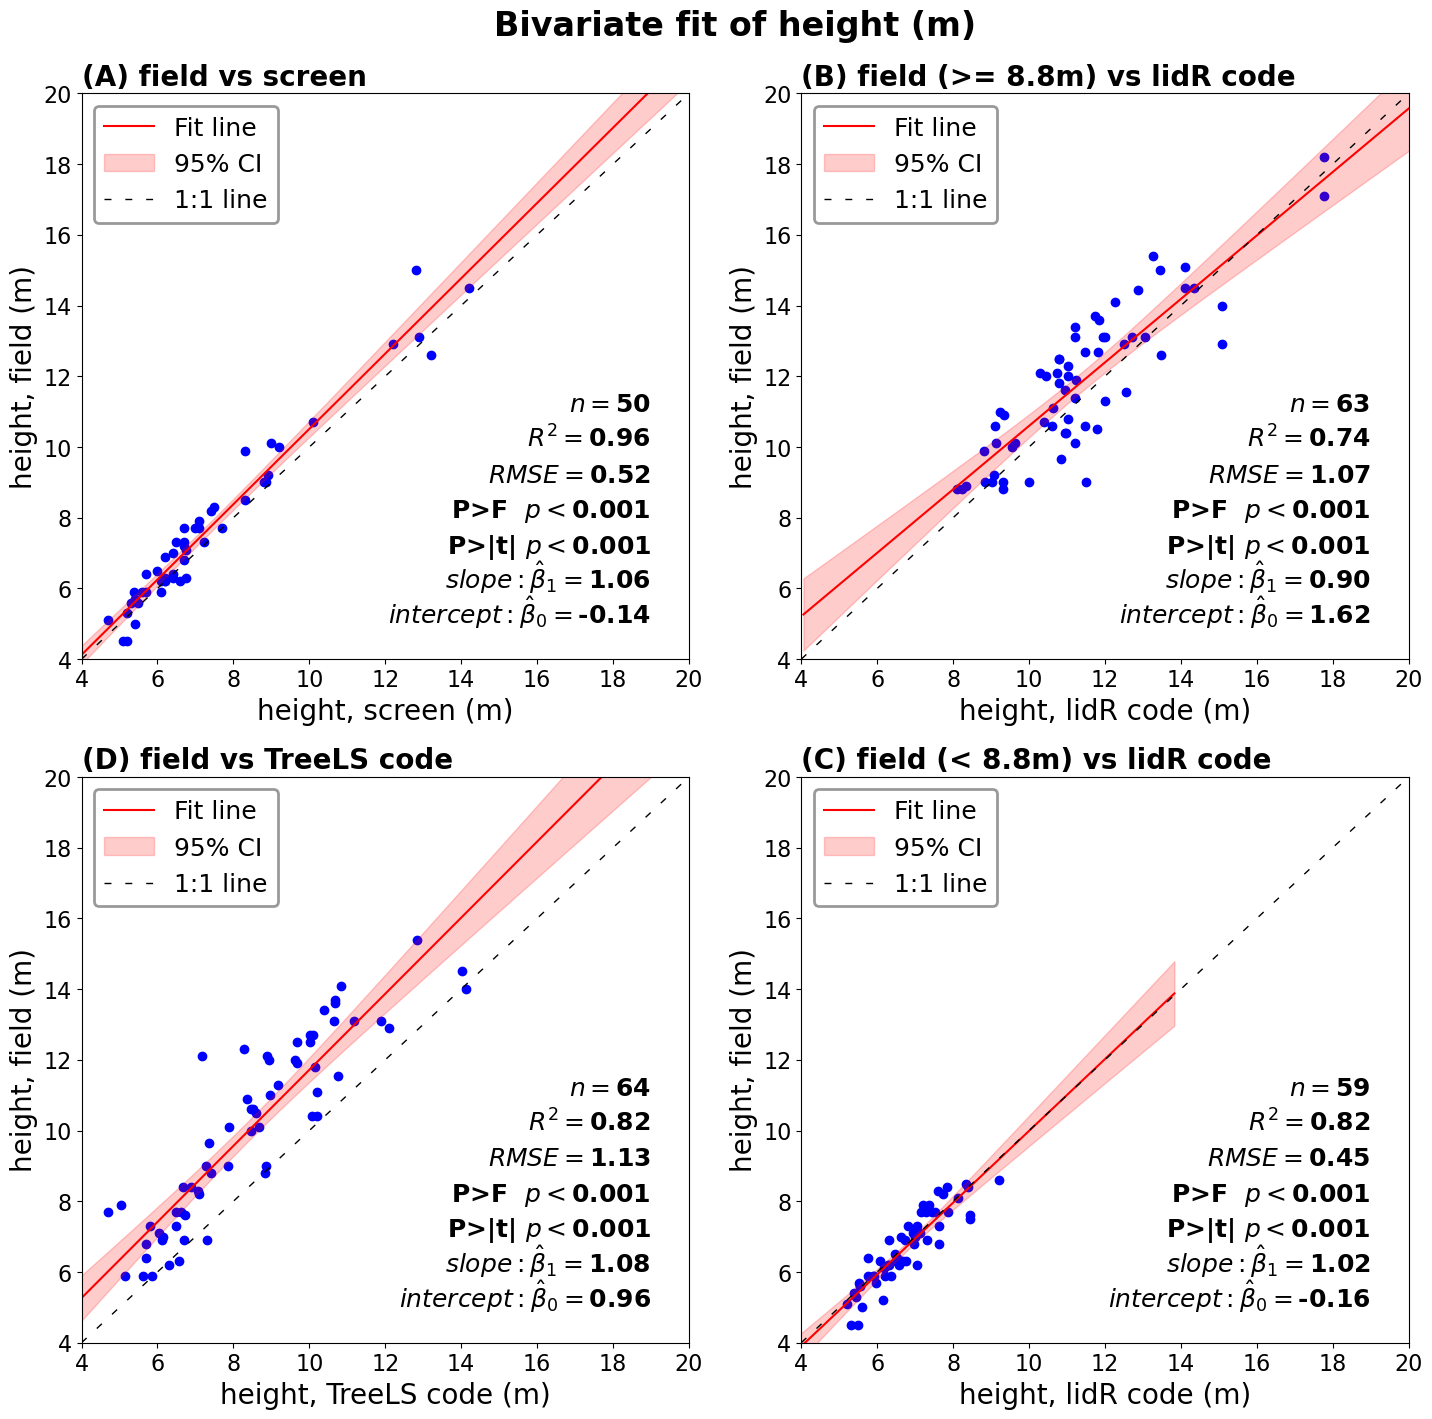

In [27]:
# Plot settings
plot_config = {
    'figsize': (14, 14),
    'title_font_size': 24,
    'ax_title_font_size': 20,
    'ax_tick_font_size': 16,
    'text_font_size': 18,
    'leg_font_size': 18,
    'text_x_start': 19,
    'text_y_start': 11,
    'step': 1,
    'ax_min': 4,
    'ax_max': 20
}

def plot_regression_with_ci(ax, data, xpar, ypar, title, xlabel, ylabel):
    x = data[xpar]
    y = data[ypar]
    x1 = np.array(x).reshape((-1, 1))

    # Fit linear regression model
    model = LinearRegression().fit(x1, y)
    r2 = model.score(x1, y)
    coefficients = model.coef_
    intercept = model.intercept_
    rmse = math.sqrt(((((intercept+coefficients[0]*x)-y)**2).sum())/(len(y)-2))

    # Fit OLS model for confidence intervals
    x_ols = sm.add_constant(x)
    ols_model = sm.OLS(y, x_ols).fit()
    pvf = ols_model.f_pvalue
    pvt = ols_model.pvalues[1]

    # Generate prediction space
    xseq = np.linspace(x.min() * 0.5, x.max() * 1.5, num=len(x))
    xseq_ols = sm.add_constant(xseq)
    predictions = ols_model.get_prediction(xseq_ols)
    conf_int = predictions.conf_int()

    # Plot data and regression line
    ax.scatter(x, y, color='b')
    ax.plot(xseq, intercept + coefficients[0] * xseq, color='r', linewidth=1.5, label='Fit line')
    ax.fill_between(xseq, conf_int[:, 0], conf_int[:, 1], color='r', alpha=0.2, label='95% CI') 
    ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls=(0, (5, 10)), color='k', linewidth=1, label='1:1 line')

    ax.set_xlim(plot_config['ax_min'], plot_config['ax_max'])
    ax.set_ylim(plot_config['ax_min'], plot_config['ax_max'])

    # Text annotations
    tx, ty, step, fs, wt, ha = plot_config['text_x_start'], plot_config['text_y_start'], plot_config['step'], plot_config['text_font_size'], 'bold', 'right'
    ax.text(tx, ty, r'$n =$' + str(len(data)), fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - step, r'$R^2 =$' + f'{r2:.2f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 2 * step, r'$RMSE = $' + f'{rmse:.2f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 3 * step, r'P>F  $p<$0.001' if pvf < 0.001 else r'P>F  $p=$' + f'{pvf:.3f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 4 * step, r'P>|t| $p<$0.001' if pvt < 0.001 else r'P>|t| $p=$' + f'{pvf:.3f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 5 * step, r'$slope: \hat\beta_1 =$' + f'{coefficients[0]:.2f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 6 * step, r'$intercept: \hat\beta_0 =$' + f'{intercept:.2f}', fontsize=fs, weight=wt, ha=ha)

    ax.set_title(title, size=plot_config['ax_title_font_size'], fontweight='bold', loc='left')
    ax.set_xlabel(xlabel, size=plot_config['ax_title_font_size'])
    ax.set_ylabel(ylabel, size=plot_config['ax_title_font_size'])
    ax.tick_params(labelsize=plot_config['ax_tick_font_size'])

    leg = ax.legend(loc='upper left', fontsize=plot_config['leg_font_size'])
    leg.get_frame().set_edgecolor('gray')
    leg.get_frame().set_linewidth(2)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=plot_config['figsize'])
fig.tight_layout(h_pad=7, w_pad=5)
fig.subplots_adjust(top=0.92) # fraction of the figure height
fig.suptitle('Bivariate fit of height (m)', size=plot_config['title_font_size'], fontweight='bold')

plot_regression_with_ci(ax1, inv_full_screen, 'h_m_mls', 'h_m_f', '(A) field vs screen', 'height, screen (m)', 'height, field (m)')
plot_regression_with_ci(ax2, inv_full_above, 'h_m_tt', 'h_m_f', '(B) field (>= 8.8m) vs lidR code', 'height, lidR code (m)', 'height, field (m)')
plot_regression_with_ci(ax3, inv_full_dt, 'h_m_tls', 'h_m_f', '(D) field vs TreeLS code', 'height, TreeLS code (m)', 'height, field (m)')
plot_regression_with_ci(ax4, inv_full_below, 'h_m_tt', 'h_m_f', '(C) field (< 8.8m) vs lidR code', 'height, lidR code (m)', 'height, field (m)')

plt.savefig(figpath + 'Scatter plots of heights 2x2 CI.png', bbox_inches='tight')
plt.show()

DBH

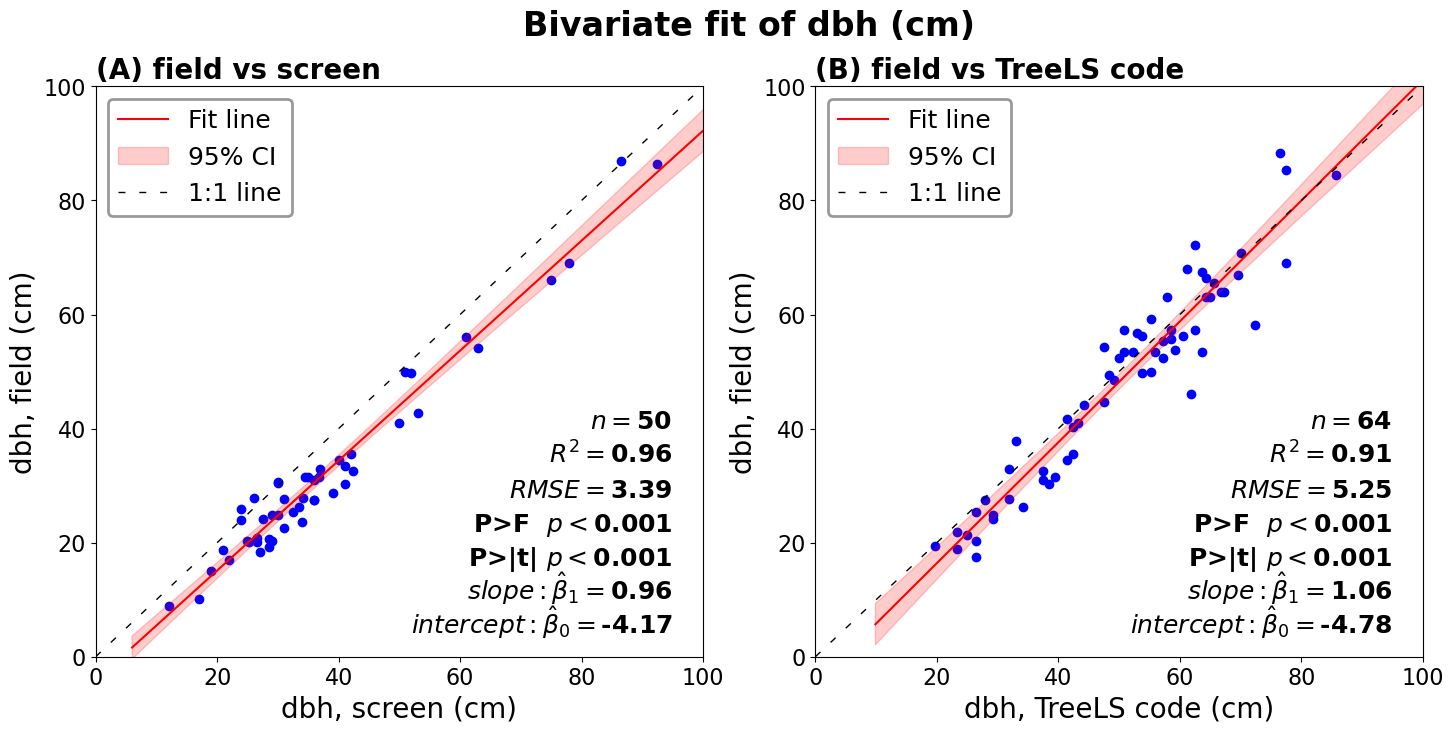

In [28]:
# Plot settings
plot_config = {
    'figsize': (14, 7),
    'title_font_size': 24,
    'ax_title_font_size': 20,
    'ax_tick_font_size': 16,
    'text_font_size': 18,
    'leg_font_size': 18,
    'text_x_start': 95,
    'text_y_start': 40,
    'step': 6,
    'ax_min': 0,
    'ax_max': 100
}

def plot_regression_with_ci(ax, data, xpar, ypar, title, xlabel, ylabel):
    x = data[xpar]
    y = data[ypar]
    x1 = np.array(x).reshape((-1, 1))

    # Fit linear regression model
    model = LinearRegression().fit(x1, y)
    r2 = model.score(x1, y)
    coefficients = model.coef_
    intercept = model.intercept_
    rmse = math.sqrt(((((intercept+coefficients[0]*x)-y)**2).sum())/(len(y)-2))

    # Fit OLS model for confidence intervals
    x_ols = sm.add_constant(x)
    ols_model = sm.OLS(y, x_ols).fit()
    pvf = ols_model.f_pvalue
    pvt = ols_model.pvalues[1]

    # Generate prediction space
    xseq = np.linspace(x.min() * 0.5, x.max() * 1.5, num=len(x))
    xseq_ols = sm.add_constant(xseq)
    predictions = ols_model.get_prediction(xseq_ols)
    conf_int = predictions.conf_int()

    # Plot data and regression line
    ax.scatter(x, y, color='b')
    ax.plot(xseq, intercept + coefficients[0] * xseq, color='r', linewidth=1.5, label='Fit line')
    ax.fill_between(xseq, conf_int[:, 0], conf_int[:, 1], color='r', alpha=0.2, label='95% CI') 
    ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls=(0, (5, 10)), color='k', linewidth=1, label='1:1 line')

    ax.set_xlim(plot_config['ax_min'], plot_config['ax_max'])
    ax.set_ylim(plot_config['ax_min'], plot_config['ax_max'])

    # Text annotations
    tx, ty, step, fs, wt, ha = plot_config['text_x_start'], plot_config['text_y_start'], plot_config['step'], plot_config['text_font_size'], 'bold', 'right'
    ax.text(tx, ty, r'$n =$' + str(len(data)), fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - step, r'$R^2 =$' + f'{r2:.2f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 2 * step, r'$RMSE = $' + f'{rmse:.2f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 3 * step, r'P>F  $p<$0.001' if pvf < 0.001 else r'P>F  $p=$' + f'{pvf:.3f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 4 * step, r'P>|t| $p<$0.001' if pvt < 0.001 else r'P>|t| $p=$' + f'{pvf:.3f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 5 * step, r'$slope: \hat\beta_1 =$' + f'{coefficients[0]:.2f}', fontsize=fs, weight=wt, ha=ha)
    ax.text(tx, ty - 6 * step, r'$intercept: \hat\beta_0 =$' + f'{intercept:.2f}', fontsize=fs, weight=wt, ha=ha)

    ax.set_title(title, size=plot_config['ax_title_font_size'], fontweight='bold', loc='left')
    ax.set_xlabel(xlabel, size=plot_config['ax_title_font_size'])
    ax.set_ylabel(ylabel, size=plot_config['ax_title_font_size'])
    ax.tick_params(labelsize=plot_config['ax_tick_font_size'])

    leg = ax.legend(loc='upper left', fontsize=plot_config['leg_font_size'])
    leg.get_frame().set_edgecolor('gray')
    leg.get_frame().set_linewidth(2)

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=plot_config['figsize'])
fig.tight_layout(h_pad=7, w_pad=5)
fig.subplots_adjust(top=0.87) # fraction of the figure height
fig.suptitle('Bivariate fit of dbh (cm)', size=plot_config['title_font_size'], fontweight='bold')

plot_regression_with_ci(ax1, inv_full_screen, 'dbh_cm_mls', 'dbh_cm_f', '(A) field vs screen', 'dbh, screen (cm)', 'dbh, field (cm)')
plot_regression_with_ci(ax2, inv_full_dt, 'dbh_cm_tls', 'dbh_cm_f', '(B) field vs TreeLS code', 'dbh, TreeLS code (cm)', 'dbh, field (cm)')

plt.savefig(figpath + 'Scatter plots of dbh 1x2 CI.png', bbox_inches='tight')
plt.show()

## Contact 

**Justinn J. Jones ’24, GISP**

Graduate Research Assistant / FAA sUAS RP

LASERS Lab / WFES 360

Department of Ecology & Conservation Biology

College of Agriculture & Life Sciences

justinn.j.jones@tamu.edu

**TEXAS A&M UNIVERSITY**